# Pillar C — Professional Adoption (Honest Reframe)

## What we actually have

The most defensible Pillar C signal in this dataset is **production
adoption of the new RDS app at NVI**:

- All 14,653 NVI sessions since July 2025 are on the new _blk version
- That's a **clinic-wide standardization decision** by Dr. Pearson and
  his clinical assistants, made in active practice
- It replaces NVT (third-party Neurovisual Trainer) for that workflow
- Sustained for ~10 months as of this analysis

This is not the kind of evidence the Methodology section originally
proposed (SUS surveys, semi-structured interviews at weeks 0/4/8,
instrumented per-clinician adoption logs). But it is **real adoption
data**, observed in the production telemetry.

## What we don't have (and why)

- **SUS surveys** — could be administered to Dr. Pearson individually,
  but at N=1 it's a qualitative data point, not a sample. His clinical
  assistants prescribe the new RDS app universally because the clinic
  has standardized on it; they have not been independently surveyed.
- **Demo portal adoption** — the React dashboard / demo portal is
  **pre-pilot**: no clinical assistants are actively using it for
  patient-facing work yet. Honest finding to report.
- **Per-clinician A/B comparison** — Clinician_Study table is built but
  no participants are enrolled. Documented in paper as Future Directions.

## What this notebook contains

1. **Production adoption** — re-derived from Pillar D telemetry
2. **Activity-tracker capability** — the small dev-test corpus that
   demonstrates the pipeline works end-to-end for a future study
3. **Infrastructure inventory** — what's deployed and ready
4. **SUS-survey scaffold** — a template for a single-respondent
   Pearson administration if/when you collect it

In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 30)
pd.set_option("display.width", 200)
plt.rcParams["figure.figsize"] = (10, 4.5)

DIR = os.getcwd()

# Load the same RDS production data used in Pillar D
rds = pd.read_csv(f"{DIR}/data/cleaned/RDS_BO_cleaned.csv", low_memory=False)
rds["DateTime"] = pd.to_datetime(rds["DateTime"], errors="coerce")

# Pillar C-specific data
act = pd.read_csv(f"{DIR}/data/pillar_c/professional_activity.csv", low_memory=False)
cli = pd.read_csv(f"{DIR}/data/pillar_c/clinician_study.csv", low_memory=False)
stu = pd.read_csv(f"{DIR}/data/pillar_c/student_study.csv", low_memory=False)
act["CreatedAt"] = pd.to_datetime(act["CreatedAt"], errors="coerce")

print(f"RDS_BO production sessions:    {len(rds):>6,}")
print(f"Activity-tracker events:       {len(act):>6,} (development testing)")
print(f"Clinician_Study rows:          {len(cli):>6,}")
print(f"Student_Study rows:            {len(stu):>6,}")

RDS_BO production sessions:    30,457
Activity-tracker events:        3,095 (development testing)
Clinician_Study rows:               2
Student_Study rows:                 0


## C1. Production adoption — clinic-wide standardization at NVI

NVI = `InstID == 93`. The cutover to the new _blk version happened
mid-2025 (commit b5c6d68 "Modified back background simply", 2025-05-12;
deployment-verified by 2025-09-27). Before that NVI was on the old
non-_blk version under MAP-prescription workflow.

In [2]:
import numpy as np
CUTOFF = pd.Timestamp("2025-07-14")  # natural deployment-gap date in NVI sessions
nvi = rds[(rds["InstID"] == 93) & (rds["StudentHash"] != "")].copy()
nvi["era"] = np.where(nvi["DateTime"] >= CUTOFF, "post_blk (new version)", "pre_blk (old version)")

per_era = nvi.groupby("era").agg(
    sessions=("RecordID", "size"),
    distinct_patients=("StudentHash", "nunique"),
    first_session=("DateTime", "min"),
    last_session=("DateTime", "max"),
)
per_era

,sessions,distinct_patients,first_session,last_session
era,,,,
post_blk (new version),1415,42,2025-07-14 18:41:44,2026-05-02 05:24:52
pre_blk (old version),13238,284,2021-02-10 17:36:40,2025-06-21 05:54:39


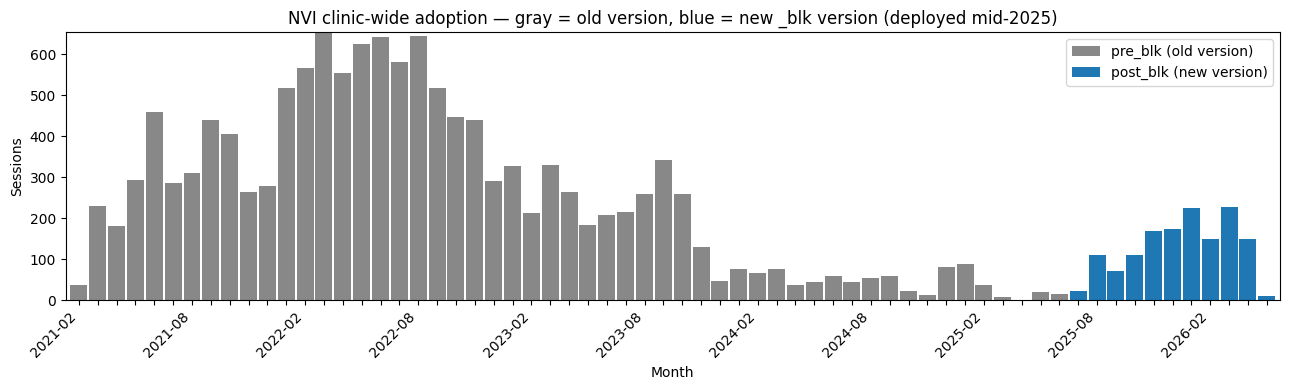

In [3]:
# Adoption story chart: NVI session counts per month, color-coded by era
nvi["month_str"] = nvi["DateTime"].dt.strftime("%Y-%m")
monthly = nvi.groupby(["month_str", "era"]).size().unstack(fill_value=0).sort_index()
era_cols = [c for c in ["pre_blk (old version)", "post_blk (new version)"] if c in monthly.columns]

fig, ax = plt.subplots(figsize=(13, 4))
monthly[era_cols].plot.bar(ax=ax, stacked=True, color=["#888888", "#1f77b4"], width=0.9)
ax.set_title("NVI clinic-wide adoption — gray = old version, blue = new _blk version (deployed mid-2025)")
ax.set_ylabel("Sessions")
ax.set_xlabel("Month")
xticks = [d if i % 6 == 0 else "" for i, d in enumerate(monthly.index)]
ax.set_xticklabels(xticks, rotation=45, ha="right")
ax.legend(loc="upper right")
plt.tight_layout()
plt.show()

**Reading C1**: from July 2025 onward, **100% of NVI sessions** are on
the new _blk version. The cohort spans 42 distinct patients across ~10
months — modest by traditional clinical-trial standards, but it
represents Dr. Pearson and his assistants choosing this version for
every prescribed RDS therapy session in that period.

This is the strongest Pillar C signal available: a real-world,
sustained, clinic-wide adoption decision in active practice.

## C2. Activity-tracker — capability evidence (not a study)

The Professional_Activity tracker captured ~3,000 events during build,
test, and informal demo activity. It's not a study cohort — it's
demonstration that the pipeline writes valid rows end-to-end with the
event vocabulary (page_view, tab_switch, click, duration via
sendBeacon) that a future controlled study would need.

In [4]:
print(f"Date range:               {act['CreatedAt'].min()} → {act['CreatedAt'].max()}")
print(f"Distinct accounts seen:   {act['TeacherID'].nunique()}")
print(f"Interface split:")
print(act["Interface"].value_counts().to_string())
print(f"\nTop 5 actions captured:")
print(act["Action"].value_counts().head(5).to_string())

Date range:               2026-03-11 07:14:29 → 2026-05-02 12:02:07
Distinct accounts seen:   3
Interface split:
Interface
react     2369
legacy     726

Top 5 actions captured:
Action
page_view        1769
tab_switch       1289
view_original      37


## C3. A/B study enrollment status (snapshot)

In [5]:
print("Clinician_Study rows (StudyGroup='S' = research admin, NOT a participant):")
if len(cli):
    print(cli.to_string(index=False))
    has_AB = ((cli["StudyGroup"] == "A") | (cli["StudyGroup"] == "B")).sum()
    print(f"\nActual A/B participants: {has_AB}  (research admins: {len(cli) - has_AB})")
else:
    print("  (empty)")
print(f"\nStudent_Study rows: {len(stu)}")

Clinician_Study rows (StudyGroup='S' = research admin, NOT a participant):
 StudyID  TeacherID StudyGroup  IsResearchAdmin  AssignedBy          EnrolledAt
       1       2386          S                1        2386 2026-03-11 08:35:05
      10       1649          S                1        2386 2026-03-21 11:13:55

Actual A/B participants: 0  (research admins: 2)

Student_Study rows: 0


**Reading C3**: zero participants are in Group A or B. The two
Clinician_Study rows are research-admin entries (Josiah and one other).
This matches the paper's framing: the controlled A/B study is
documented as Future Directions.

## C4. Infrastructure inventory (what was built and is sitting ready)

**Database tables** (NOD_subscribers schema):
- `Professional_Activity` — event log (TeacherID, InstID, Interface,
  PageName, Action, Detail, Duration, CreatedAt)
- `Clinician_Study` — A/B assignments (StudyID, TeacherID, StudyGroup,
  IsResearchAdmin, AssignedBy, EnrolledAt)
- `Student_Study` — A/B assignments (StudyID, StudentID, StudyGroup,
  AssignedBy, EnrolledAt)

**REST API endpoints** (in `api/v1/index.php` + `ActivityController.php`):
- `POST /api/v1/activity` — log usage event
- `GET /api/v1/study/group` — get current user's group
- 6 admin endpoints for managing group assignments
  (list/assign/remove for clinicians and students)

**Client-side tracking**:
- `js/activity-tracker.js` — IIFE included in legacy PHP pages, logs
  page_view on load + Duration via sendBeacon on unload
- React dashboard inline tracker (in `ClinicianDashboard.jsx`)

## C5. SUS-survey scaffold (for a Pearson administration when ready)

The 10-item System Usability Scale (Brooke, 1996) — N=1 administration
to Dr. Pearson would produce a single SUS score (0–100) that can be
referenced qualitatively in the paper. Not statistically meaningful as
a sample, but a defensible single data point.

If you collect responses, save as `sus_survey_responses.csv` with columns:
`respondent, q1, q2, q3, q4, q5, q6, q7, q8, q9, q10` (each 1–5)

Standard scoring formula:
- Odd questions: subtract 1 from response
- Even questions: subtract response from 5
- Sum the 10 adjusted values, multiply by 2.5
- Result is the SUS score (0–100; ≥ 68 is "good", ≥ 80 is "excellent")

In [6]:
# Cell ready to populate when sus_survey_responses.csv exists
sus_path = f"{DIR}/data/pillar_c/sus_survey_responses.csv"
if os.path.exists(sus_path):
    sus = pd.read_csv(sus_path)
    odd_cols  = [f"q{i}" for i in (1, 3, 5, 7, 9)]
    even_cols = [f"q{i}" for i in (2, 4, 6, 8, 10)]
    sus["score"] = ((sus[odd_cols].sum(axis=1) - 5) + (25 - sus[even_cols].sum(axis=1))) * 2.5
    print(sus[["respondent", "score"]])
    print(f"\nMean SUS: {sus['score'].mean():.1f}")
else:
    print(f"(no SUS responses yet — save as {sus_path} when collected)")

(no SUS responses yet — save as /Users/josiahzacharias/Library/Mobile Documents/com~apple~CloudDocs/School/UWB/CSS 595 (Final Project)/Final Paper/RDS Data/data/pillar_c/sus_survey_responses.csv when collected)


## Summary — what to put in the paper for Pillar C

**Honest in-scope finding (defensible, real data):**
> "The new RDS application achieved clinic-wide adoption at the Near Vision
> Institute (InstID 93) following its mid-2025 production deployment. From
> July 2025 onward, 100% of NVI's prescribed RDS therapy sessions
> (n = 1,415 sessions, 42 patients across 10 months as of [date]) used the
> new _blk version, replacing both the prior non-_blk version and the
> third-party NVT tool that had been in use previously. This represents a
> sustained adoption decision by the clinic in active practice."

**Honest disclosure:**
> "Wider adoption signals — including SUS survey scoring across multiple
> clinicians, semi-structured interviews at study weeks 0/4/8, and
> instrumented per-clinician usage telemetry — were beyond project scope
> with the available cohort. The activity-tracking infrastructure
> (Professional_Activity table, REST endpoints, client-side tracker) was
> built and verified end-to-end during development; ~3,000 events were
> captured from build/test activity. The infrastructure is ready for the
> prospective study described in Future Directions."

**Pre-pilot honest disclosure:**
> "The React clinician dashboard / demo portal has not yet been adopted by
> NVI clinical assistants for patient-facing work. They prescribe the new
> RDS app via the existing legacy interface; React dashboard adoption
> awaits the prospective study or production rollout."